# EquiLoan — Master EDA & Model Comparison Notebook
**Project:** Unbiased Loan Approval Prediction System with Demographic Bias Auditing
**Dataset:** Kaggle Loan Approval Dataset — Ashish Gupta (2022)
**Base Paper:** Haque & Hassan (2024)

---
## Bugs Fixed From Previous Version

| # | Bug | Fix |
|---|-----|-----|
| 1 | `df.describe()` shown on **raw uncleaned data** | `df_clean.describe()` shown after preprocessing |
| 2 | Post-preprocessing health checks placed **inside EDA** (Section 2) — `df_clean` not yet defined | Moved to Section 3 after preprocessing pipeline |
| 3 | **6 duplicate cells** (Steps 1–5 fully duplicated) | Removed all duplicates — each step appears exactly once |
| 4 | Two identical "Defensive guard" cells | Removed redundant copy |
| 5 | Missing values chart plotted **twice** (cells 12 & 13 identical logic) | Single clean missingness chart |
| 6 | `df_eda` imputed with raw medians — `df.describe()` showed pre-imputation stats | Removed raw describe, show cleaned stats only |
| 7 | Fairness bivariate cell mixed into correlation section without clear label | Moved to its own clearly labelled cell |

---
## SECTION 0 — Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = 'status'
print('All imports successful')

All imports successful


---
## SECTION 1 — Load & Inspect Raw Data
> Raw data inspection only — statistics shown here are **before cleaning**. Cleaned statistics shown after Section 3.

In [ ]:
# Load raw data
df = pd.read_csv('/content/loan_v2 (1).csv')

print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Target : {TARGET}')
df.head()

Shape  : 148,670 rows x 37 columns
Memory : 185.9 MB
Target : status


,Unnamed: 0,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,high_interest_rate,senior_age
0,126324,151214,2019,cf,Male,nopre,type3,p3,l1,nopc,...,EXP,35-44,to_inst,70.063920,North,direct,0,42.000000,1.0,0.000000
1,13385,38275,2019,cf,Joint,nopre,type2,p4,l1,nopc,...,EXP,>74,not_inst,40.327381,North,direct,0,40.000000,0.0,2.703094
2,98606,123496,2019,cf,Sex Not Available,nopre,type1,p4,l1,nopc,...,CIB,55-64,to_inst,77.388009,south,direct,0,29.000000,1.0,1.000000
3,7184,32074,2019,cf,Female,nopre,type1,p3,l1,nopc,...,CIB,35-44,to_inst,74.280576,North,direct,0,44.000000,1.0,0.000000
4,120745,145635,2019,cf,Male,nopre,type1,p1,l1,nopc,...,CIB,35-44,not_inst,99.107143,North,direct,0,148.317616,0.0,0.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 37 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 148670 non-null  int64  
 1   id                         148670 non-null  int64  
 2   year                       148670 non-null  int64  
 3   loan_limit                 145673 non-null  object 
 4   gender                     148670 non-null  object 
 5   approv_in_adv              147855 non-null  object 
 6   loan_type                  148670 non-null  object 
 7   loan_purpose               148550 non-null  object 
 8   credit_worthiness          148670 non-null  object 
 9   open_credit                148670 non-null  object 
 10  business_or_commercial     148670 non-null  object 
 11  loan_amount                148670 non-null  float64
 12  rate_of_interest           148670 non-null  float64
 13  interest_rate_spread       11

In [ ]:
# BUG FIX: Removed df.describe() here — raw stats on uncleaned data
# are misleading. Cleaned describe() is shown after preprocessing in Section 3.
# Instead, show just missing values and target distribution on raw data.

# Missing values in raw data
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_report)}')
print()
print(missing_report.to_string())

Columns with missing values: 13

                           Missing Count  Missing %
upfront_charges                    39231      26.39
interest_rate_spread               36283      24.41
dtir1                              23899      16.08
property_value                     14952      10.06
ltv                                14942      10.05
income                              9046       6.08
loan_limit                          2997       2.02
approv_in_adv                        815       0.55
submission_of_application            180       0.12
age                                  181       0.12
loan_purpose                         120       0.08
neg_ammortization                    112       0.08
term                                  41       0.03


In [ ]:
# Target distribution on raw data
print('Target column:', TARGET)
print(df[TARGET].value_counts())
print()
print('Class balance (%):')
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Target column: status
status
0    111273
1     37397
Name: count, dtype: int64

Class balance (%):
status
0    74.85
1    25.15
Name: proportion, dtype: float64


---
## SECTION 2 — Exploratory Data Analysis (EDA)
> **Important:** EDA uses `df_eda` — a copy with missing values imputed for visualization.
> This is separate from `df_clean` used for modelling.
> All EDA happens **before** modelling so findings feed into preprocessing decisions.

In [ ]:
# Create EDA copy — imputed for visualization only
# BUG FIX: This is df_eda — separate from df_clean used in modelling
DROP_COLS = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_eda = df.drop(columns=DROP_COLS).copy()

# Impute for visualization only
num_cols_eda = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_eda = df_eda.select_dtypes(include=['object']).columns.tolist()

for col in num_cols_eda:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())
for col in cat_cols_eda:
    df_eda[col] = df_eda[col].fillna(df_eda[col].mode()[0])

print(f'df_eda shape       : {df_eda.shape}')
print(f'Missing remaining  : {df_eda.isnull().sum().sum()}')
print('(This copy is for EDA visualization only — modelling uses df_clean from Section 3)')

df_eda shape       : (148670, 34)
Missing remaining  : 0
(This copy is for EDA visualization only — modelling uses df_clean from Section 3)


### 2.1 Missing Data Overview (Raw Data)

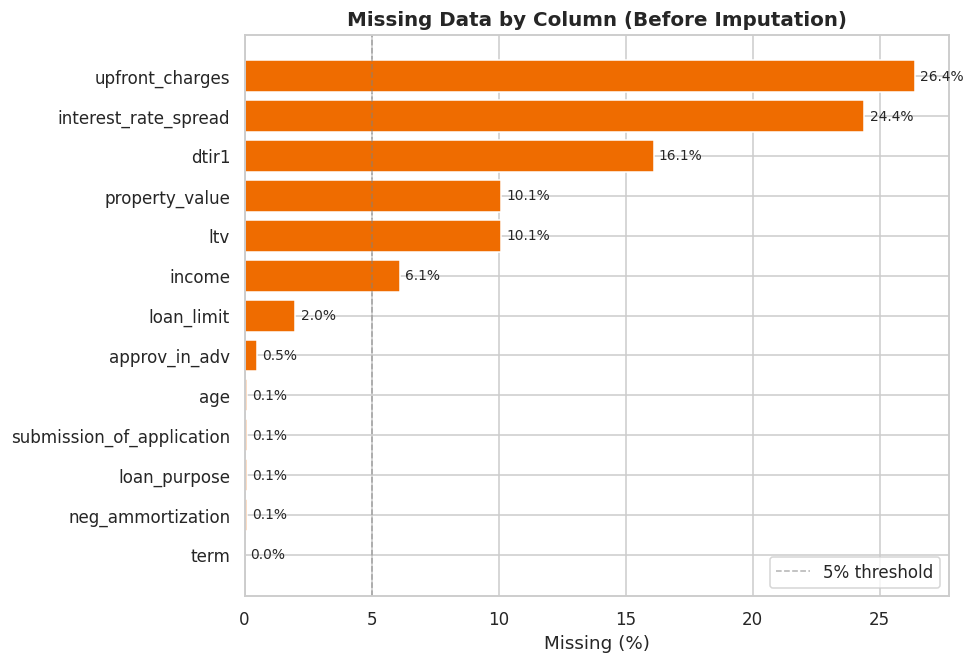

13 columns have missing values (0.0% to 26.4%)
Strategy: median imputation for numeric, mode for categorical (applied in Section 3 Step 4)


In [ ]:
# BUG FIX: Single missingness chart (previously plotted twice identically)
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=True)
miss_pct = (miss / len(df) * 100).round(1)

if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, len(miss) * 0.4 + 1)))
    bars = ax.barh(miss_pct.index, miss_pct.values, color='#EF6C00', edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Data by Column (Before Imputation)', fontweight='bold', fontsize=13)
    ax.axvline(5, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='5% threshold')
    ax.legend()
    for bar, val in zip(bars, miss_pct.values):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'{len(miss)} columns have missing values ({miss_pct.min()}% to {miss_pct.max()}%)')
    print('Strategy: median imputation for numeric, mode for categorical (applied in Section 3 Step 4)')
else:
    print('No missing values in raw data')

### 2.2 Target Variable Distribution

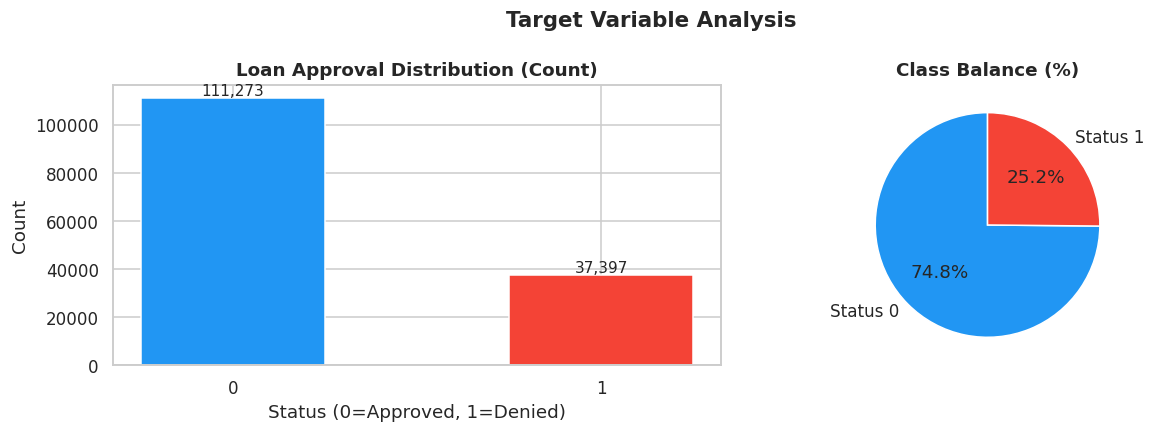

Class imbalance ratio: 2.98:1
Imbalance present — use F1-Score and ROC-AUC as primary metrics, not accuracy alone.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df_eda[TARGET].value_counts()
axes[0].bar(vc.index.astype(str), vc.values,
            color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Approval Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Status (0=Approved, 1=Denied)')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.01, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(vc.values,
            labels=[f'Status {i}' for i in vc.index],
            autopct='%1.1f%%',
            colors=['#2196F3','#F44336'],
            startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Balance (%)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance = vc.max() / vc.min()
print(f'Class imbalance ratio: {imbalance:.2f}:1')
print('Imbalance present — use F1-Score and ROC-AUC as primary metrics, not accuracy alone.')

### 2.3 Numerical Feature Distributions

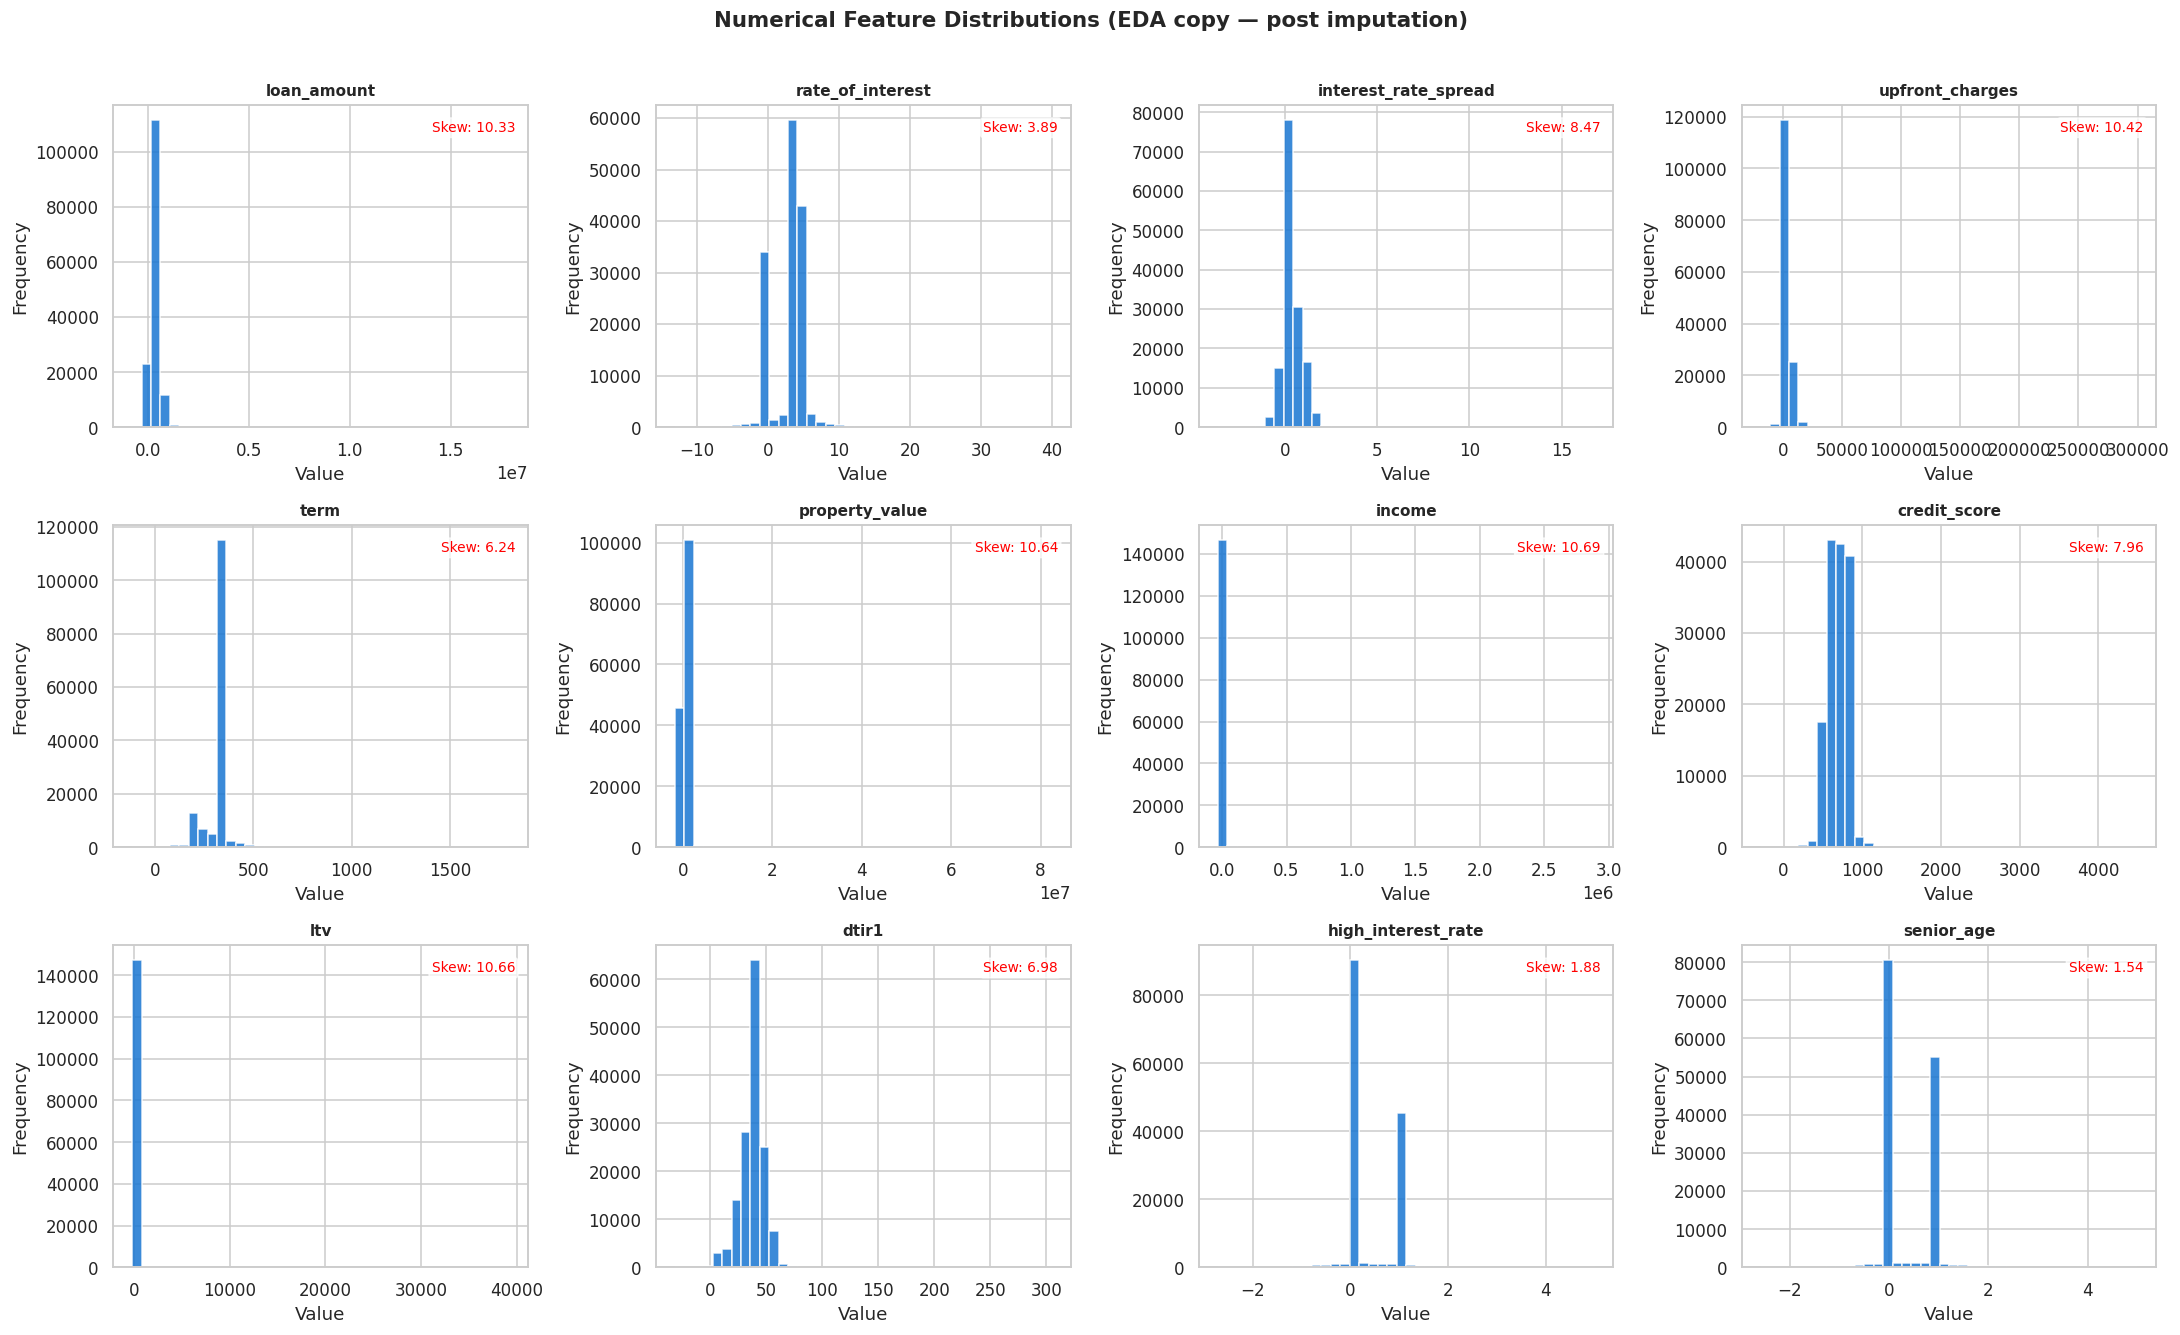

In [ ]:
num_features = [c for c in num_cols_eda if c != TARGET]
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df_eda[col].dropna(), bins=40, color='#1976D2', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    skew = df_eda[col].skew()
    color = 'red' if abs(skew) > 1 else 'green'
    axes[i].text(0.97, 0.95, f'Skew: {skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color=color,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions (EDA copy — post imputation)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Outlier Detection — Before IQR Clipping

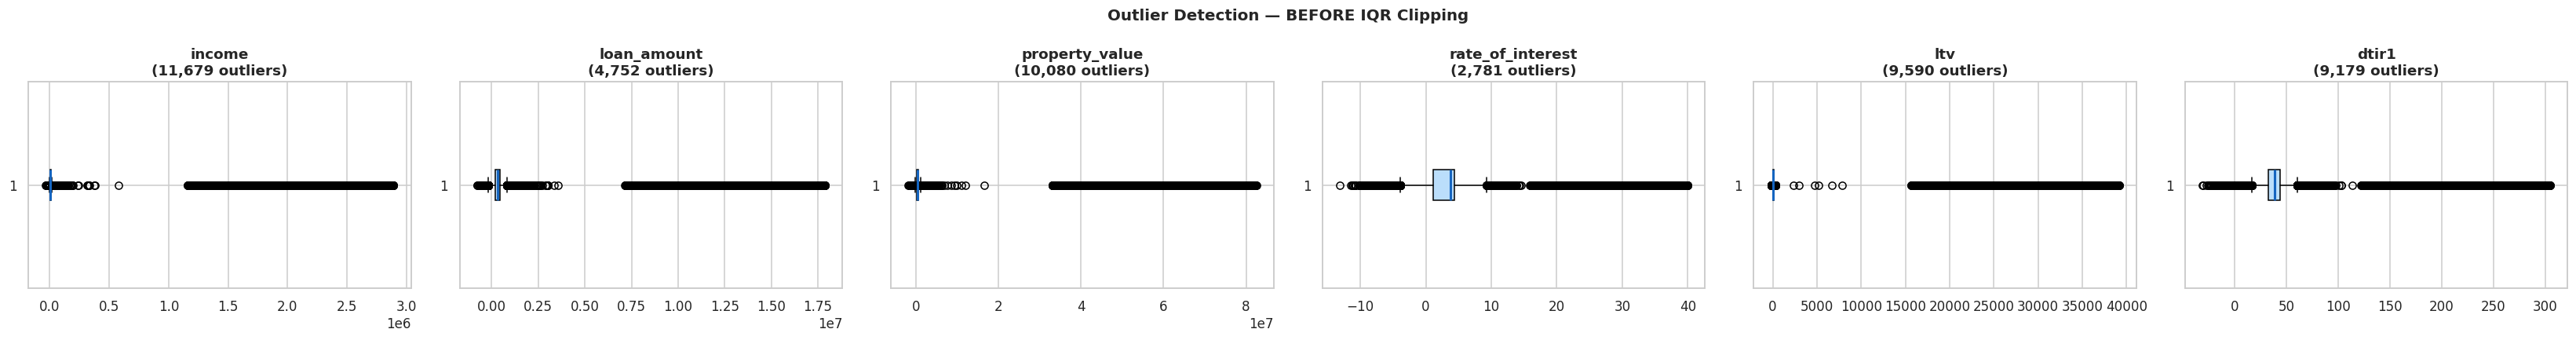

Outlier counts before clipping:
          Column  Outliers  Pct
          income     11679 7.9%
     loan_amount      4752 3.2%
  property_value     10080 6.8%
rate_of_interest      2781 1.9%
             ltv      9590 6.5%
           dtir1      9179 6.2%


In [ ]:
iqr_cols = [c for c in ['income', 'loan_amount', 'property_value',
                        'rate_of_interest', 'ltv', 'dtir1']
            if c in df_eda.columns]

if iqr_cols:
    fig, axes = plt.subplots(1, len(iqr_cols), figsize=(5 * len(iqr_cols), 4))
    if len(iqr_cols) == 1:
        axes = [axes]

    outlier_summary = []
    for ax, col in zip(axes, iqr_cols):
        ax.boxplot(df_eda[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#BBDEFB'),
                   medianprops=dict(color='#1565C0', linewidth=2))
        Q1 = df_eda[col].quantile(0.25)
        Q3 = df_eda[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum()
        ax.set_title(f'{col}\n({n_out:,} outliers)', fontweight='bold')
        outlier_summary.append({'Column': col, 'Outliers': n_out,
                                 'Pct': f'{n_out/len(df_eda)*100:.1f}%'})

    plt.suptitle('Outlier Detection — BEFORE IQR Clipping', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('Outlier counts before clipping:')
    print(pd.DataFrame(outlier_summary).to_string(index=False))
else:
    print('No IQR target columns found in dataset')

### 2.5 Correlation Heatmap

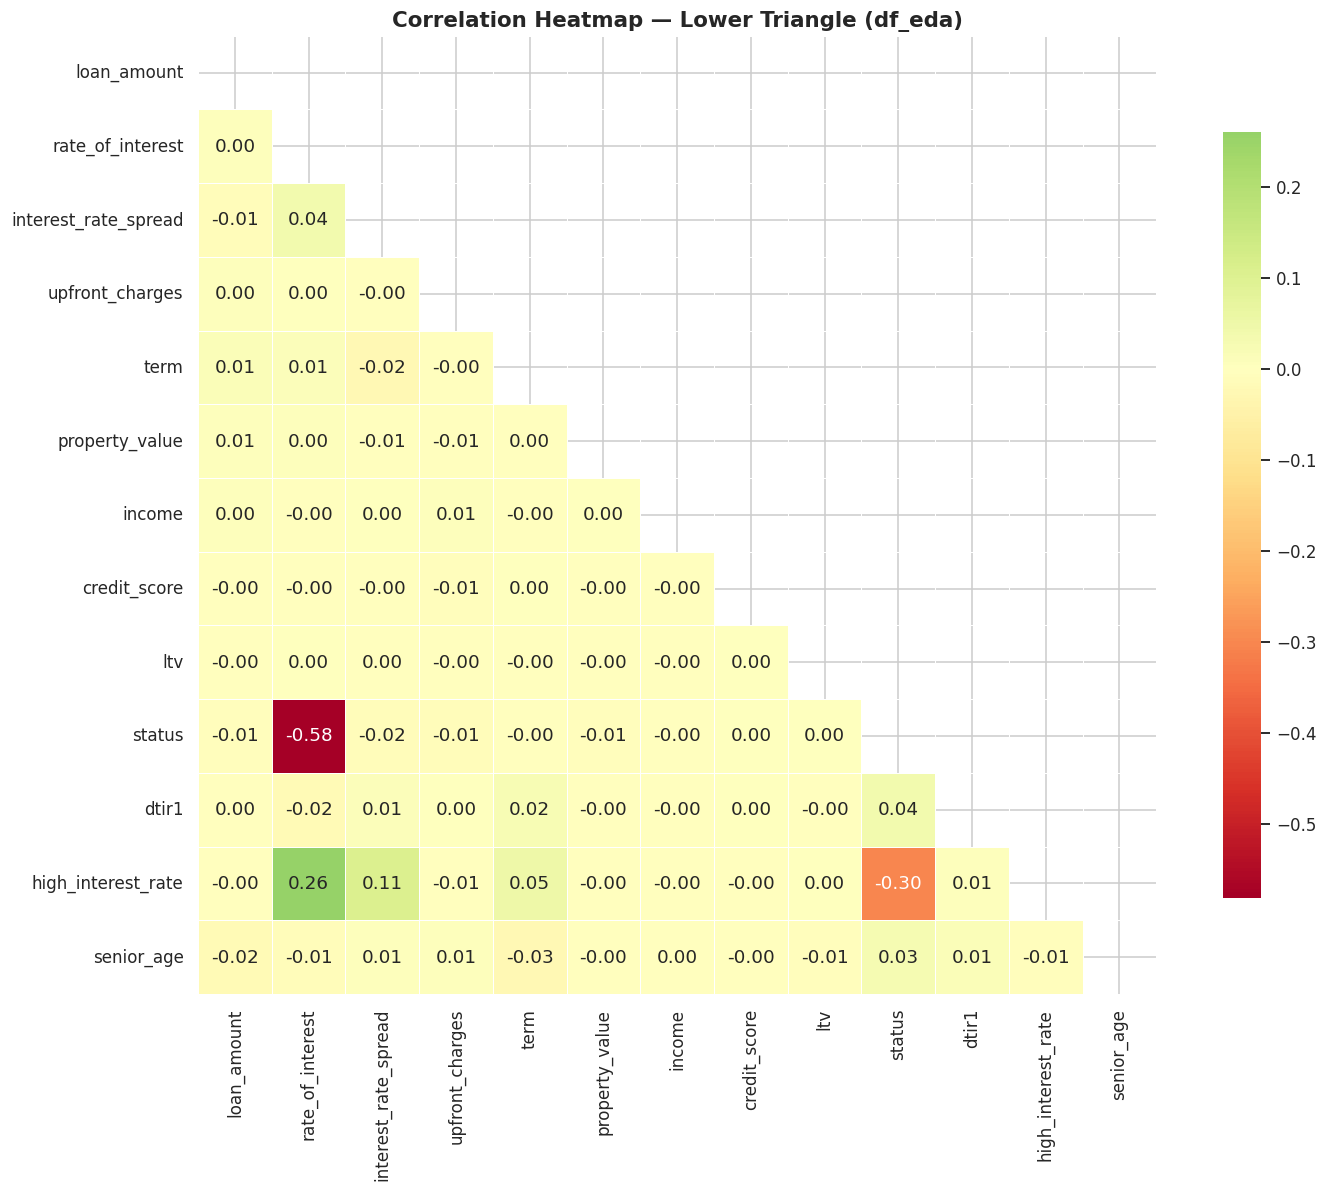

Top 10 features correlated with target:
rate_of_interest        0.582
high_interest_rate      0.300
dtir1                   0.038
senior_age              0.030
interest_rate_spread    0.015
upfront_charges         0.010
property_value          0.006
loan_amount             0.006
term                    0.004
ltv                     0.003


In [ ]:
num_only = df_eda.select_dtypes(include=['int64', 'float64'])
corr = num_only.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdYlGn', center=0,
    annot=len(corr) <= 20, fmt='.2f',
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Lower Triangle (df_eda)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Top 10 features correlated with target:')
print(target_corr.head(10).round(3).to_string())

### 2.6 Dominant Feature Investigation
> If `rate_of_interest` shows a very high correlation with `status`, this explains strong baseline performance and should be flagged as a modelling caveat.

Most correlated feature with target: rate_of_interest (r=0.582)
This may drive most of Logistic Regression performance on its own.


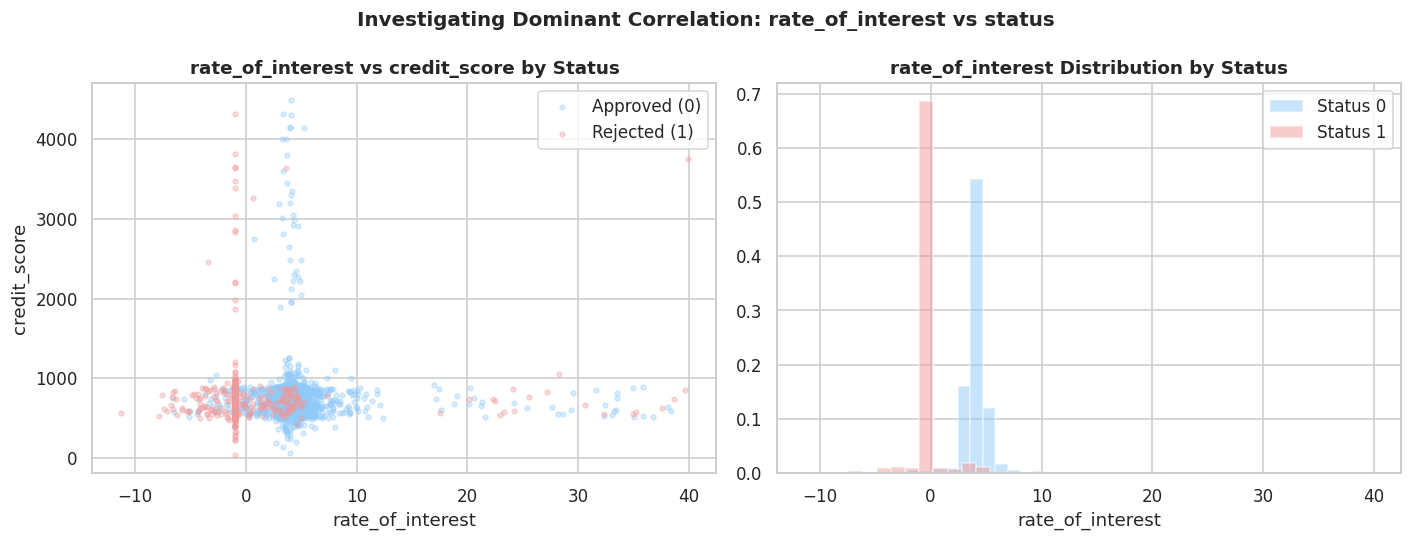

In [ ]:
dominant_col = target_corr.index[0]  # highest correlated feature
second_col = 'credit_score' if 'credit_score' in df_eda.columns else target_corr.index[1]

print(f'Most correlated feature with target: {dominant_col} (r={target_corr[dominant_col]:.3f})')
print(f'This may drive most of Logistic Regression performance on its own.')

sample = df_eda.sample(n=min(6000, len(df_eda)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
for status_val, color, label in zip(
    sorted(sample[TARGET].unique()),
    ['#90CAF9', '#EF9A9A'],
    ['Approved (0)', 'Rejected (1)']
):
    subset = sample[sample[TARGET] == status_val]
    if dominant_col in subset.columns and second_col in subset.columns:
        axes[0].scatter(subset[dominant_col], subset[second_col],
                        s=10, alpha=0.35, color=color, label=label)

axes[0].set_xlabel(dominant_col)
axes[0].set_ylabel(second_col)
axes[0].set_title(f'{dominant_col} vs {second_col} by Status', fontweight='bold')
axes[0].legend()

# KDE plot
if dominant_col in sample.columns:
    for status_val, color in zip(sorted(sample[TARGET].unique()), ['#90CAF9', '#EF9A9A']):
        subset = sample[sample[TARGET] == status_val][dominant_col]
        axes[1].hist(subset, bins=40, alpha=0.5, color=color,
                     label=f'Status {status_val}', density=True)
    axes[1].set_title(f'{dominant_col} Distribution by Status', fontweight='bold')
    axes[1].set_xlabel(dominant_col)
    axes[1].legend()

plt.suptitle(f'Investigating Dominant Correlation: {dominant_col} vs {TARGET}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Categorical Feature Distributions

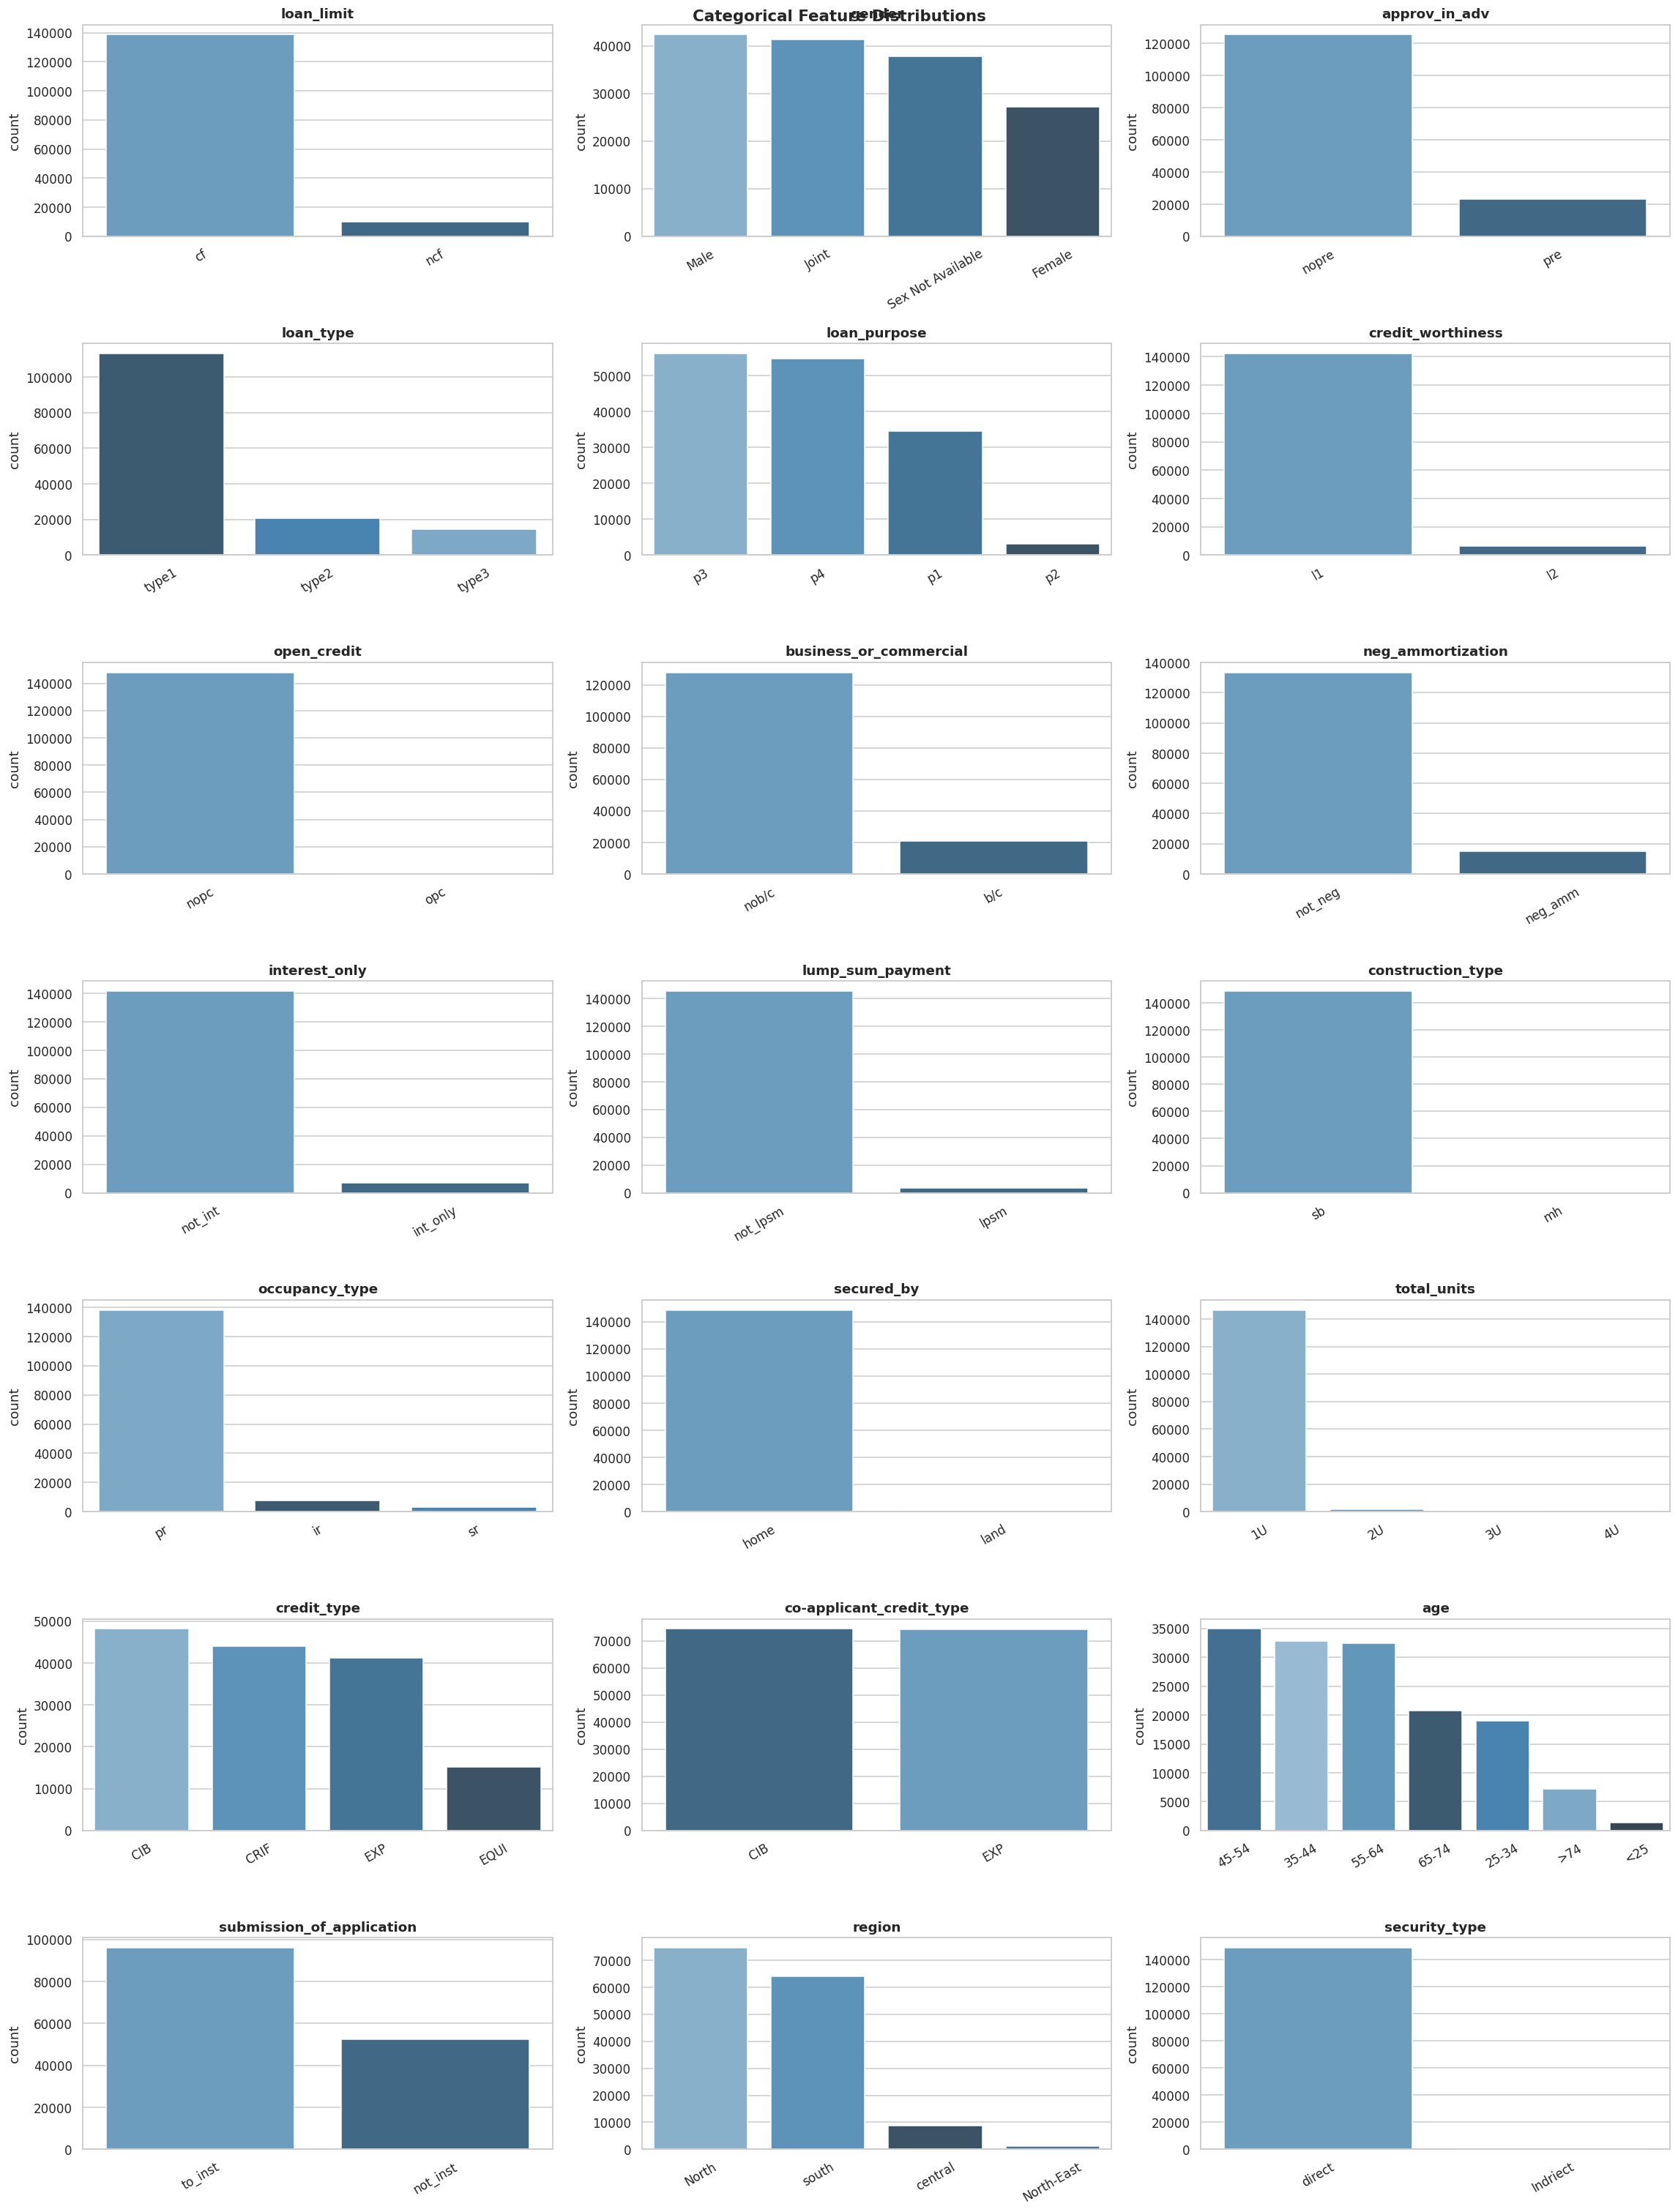

In [ ]:
cat_features = [c for c in cat_cols_eda if c != TARGET]

if cat_features:
    n_cols_cat = min(3, len(cat_features))
    n_rows_cat = (len(cat_features) + n_cols_cat - 1) // n_cols_cat
    fig, axes = plt.subplots(n_rows_cat, n_cols_cat,
                              figsize=(7 * n_cols_cat, 4 * n_rows_cat))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_features):
        order = df_eda[col].value_counts().index
        sns.countplot(x=col, data=df_eda, order=order, ax=axes[i],
                      hue=col, palette='Blues_d', legend=False)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No categorical features found')

### 2.8 SDG 10 — Approval Rate by Demographic Group
> This is the **core fairness evidence** for your project. Groups with lower approval rates despite equal financial profiles indicate historical bias.

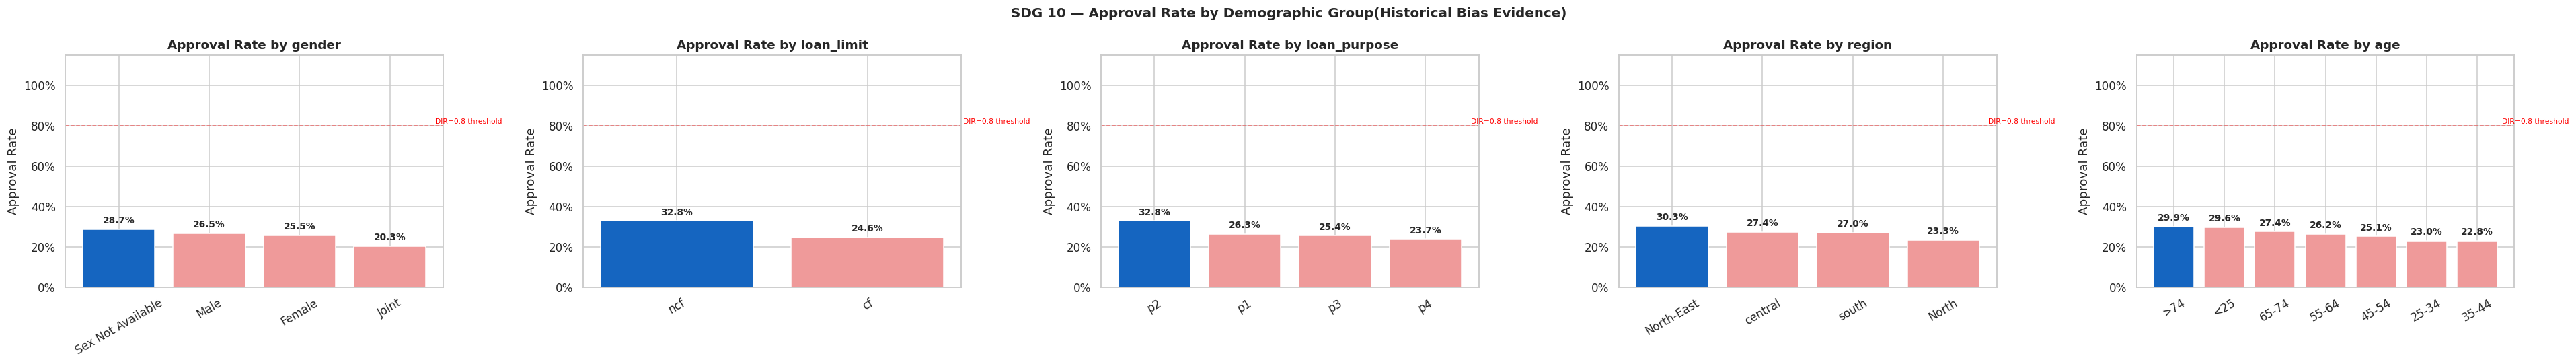

In [ ]:
fairness_cols = [c for c in ['gender', 'loan_limit', 'loan_purpose', 'region', 'age']
                 if c in df_eda.columns]

if fairness_cols:
    n = len(fairness_cols)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, fairness_cols):
        approval_rate = df_eda.groupby(col)[TARGET].mean().sort_values(ascending=False)
        colors_bar = ['#1565C0' if v == approval_rate.max() else '#EF9A9A'
                      for v in approval_rate.values]
        bars = ax.bar(approval_rate.index.astype(str), approval_rate.values,
                      color=colors_bar, edgecolor='white')
        ax.set_title(f'Approval Rate by {col}', fontweight='bold')
        ax.set_ylabel('Approval Rate')
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, approval_rate.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                    f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

        # Mark 80% DIR threshold
        ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(len(approval_rate)-0.5, 0.81, 'DIR=0.8 threshold', fontsize=7, color='red')

    plt.suptitle('SDG 10 — Approval Rate by Demographic Group(Historical Bias Evidence)',fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No fairness-sensitive columns (gender/region/loan_limit) found in dataset')

### 2.9 Financial Features vs Loan Status

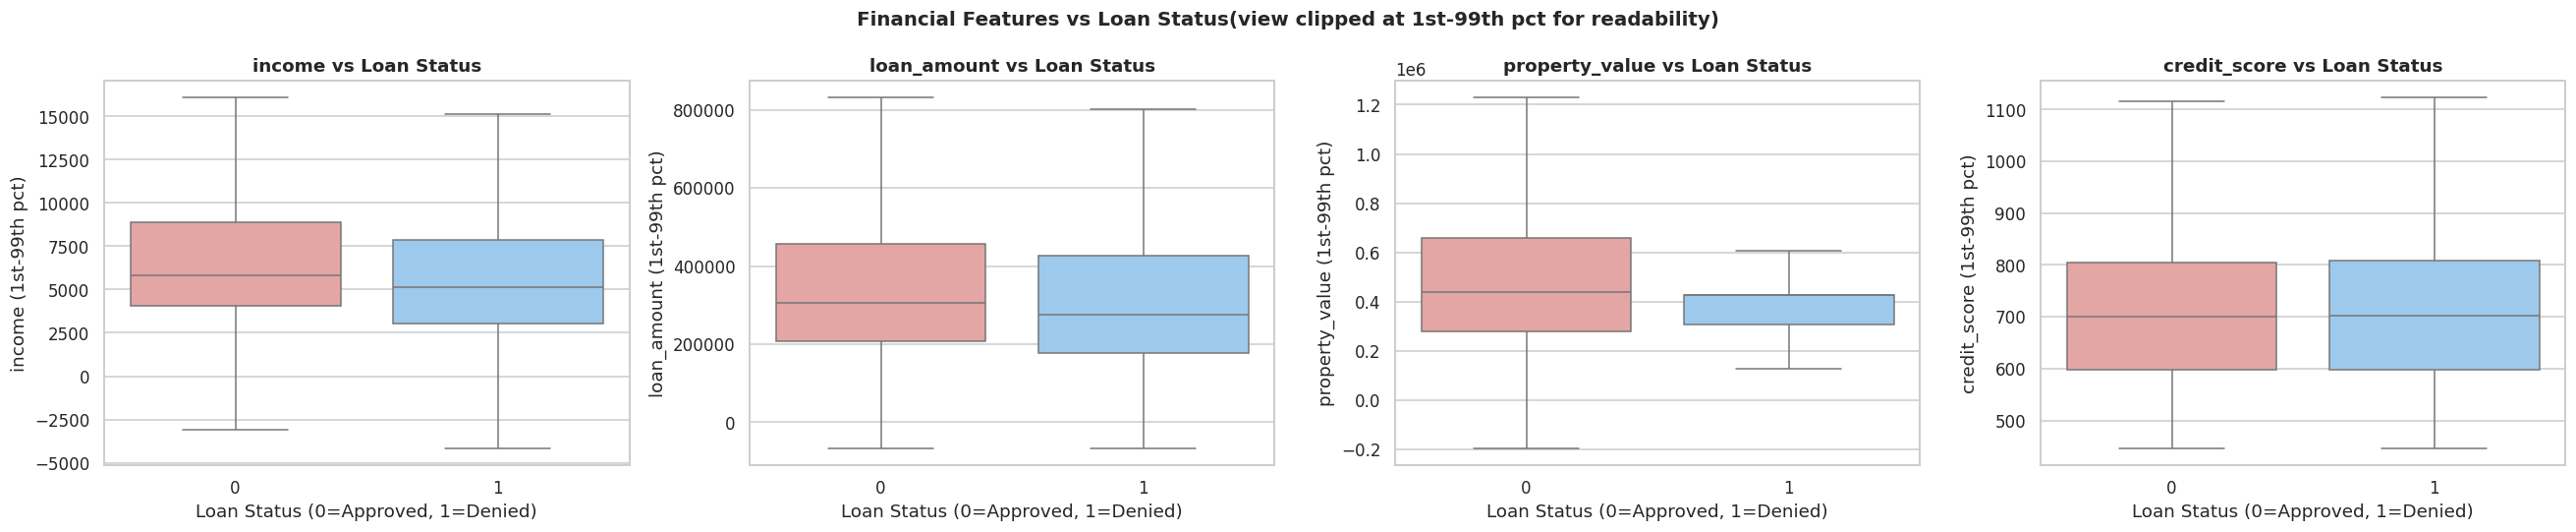

In [ ]:
compare_cols = [c for c in ['income', 'loan_amount', 'property_value', 'credit_score']
                if c in df_eda.columns]

if compare_cols:
    fig, axes = plt.subplots(1, len(compare_cols), figsize=(6 * len(compare_cols), 5))
    if len(compare_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, compare_cols):
        # Clip to 1st-99th pct for readability (extreme outliers collapse the box otherwise)
        lo, hi = df_eda[col].quantile([0.01, 0.99])
        plot_vals = df_eda[col].clip(lo, hi)
        sns.boxplot(x=df_eda[TARGET].astype(str), y=plot_vals, ax=ax,
                    hue=df_eda[TARGET].astype(str), legend=False,
                    palette=['#EF9A9A', '#90CAF9'], showfliers=False)
        ax.set_title(f'{col} vs Loan Status', fontweight='bold')
        ax.set_xlabel('Loan Status (0=Approved, 1=Denied)')
        ax.set_ylabel(f'{col} (1st-99th pct)')

    plt.suptitle('Financial Features vs Loan Status(view clipped at 1st-99th pct for readability)',fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## SECTION 3 — Preprocessing Pipeline
> **BUG FIX:** Each step appears exactly once (Steps 1–5 were fully duplicated in previous version).
> Post-preprocessing health checks are here — after `df_clean` is built — not in Section 2.

In [ ]:
# STEP 1: Drop non-predictive ID columns
# BUG FIX: df_clean defined exactly once — not redefined later
DROP_COLS = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_clean = df.drop(columns=DROP_COLS).copy()

print(f'Step 1 | Shape after dropping ID cols: {df_clean.shape}')
print(f'        Dropped: {DROP_COLS if DROP_COLS else "none"}')

Step 1 | Shape after dropping ID cols: (148670, 34)
        Dropped: ['Unnamed: 0', 'id', 'year']


In [ ]:
# STEP 2: Remove rows where target is null
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].notna()].copy()
after = len(df_clean)
print(f'Step 2 | Rows removed (null target) : {before - after:,}')
print(f'        Rows remaining              : {after:,}')

Step 2 | Rows removed (null target) : 0
        Rows remaining              : 148,670


In [ ]:
# STEP 3: Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Step 3 | Duplicate rows removed : {before - after:,}')
print(f'        Rows remaining          : {after:,}')

Step 3 | Duplicate rows removed : 0
        Rows remaining          : 148,670


In [ ]:
# STEP 4: Impute missing values
num_cols = [c for c in df_clean.select_dtypes(include=['int64','float64']).columns if c != TARGET]
cat_cols = [c for c in df_clean.select_dtypes(include=['object']).columns if c != TARGET]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'Step 4 | Missing values after imputation: {df_clean.isnull().sum().sum()}')
print(f'        Numeric cols imputed : {len(num_cols)} (median)')
print(f'        Categorical cols imputed: {len(cat_cols)} (mode)')

Step 4 | Missing values after imputation: 0
        Numeric cols imputed : 12 (median)
        Categorical cols imputed: 21 (mode)


In [ ]:
# STEP 5: IQR outlier clipping — applied BEFORE extracting X
iqr_target_cols = [c for c in ['income', 'loan_amount', 'property_value',
                                'rate_of_interest', 'ltv', 'dtir1']
                   if c in df_clean.columns]

clip_log = []
for col in iqr_target_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    clip_log.append({'Column': col, 'Lower Fence': round(lower,2),
                     'Upper Fence': round(upper,2), 'Rows Clipped': n_clipped})

print('Step 5 | IQR Clipping Summary:')
print(pd.DataFrame(clip_log).to_string(index=False))

Step 5 | IQR Clipping Summary:
          Column  Lower Fence  Upper Fence  Rows Clipped
          income     -3510.00     15930.00         11679
     loan_amount   -178500.00    821500.00          4752
  property_value   -207000.00   1113000.00         10080
rate_of_interest        -3.85         9.31          2781
             ltv        26.38       121.71          9590
           dtir1        16.50        60.50          9179


In [ ]:
# STEP 6: Extract X and y — single definition
X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

assert TARGET not in X.columns, f'LEAKAGE BUG: {TARGET} is still in X!'

print(f'Step 6 | X shape : {X.shape}')
print(f'         y shape : {y.shape}')
print(f'         Classes : {sorted(y.unique())}')
print(f'         Distribution: {y.value_counts().to_dict()}')

Step 6 | X shape : (148670, 33)
         y shape : (148670,)
         Classes : [np.int64(0), np.int64(1)]
         Distribution: {0: 111273, 1: 37397}


In [ ]:
# STEP 7: One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Clean column names for XGBoost compatibility
X_encoded.columns = (
    X_encoded.columns
    .str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
    .str.strip('_')
)

# Safety check for target leakage
status_leak = [c for c in X_encoded.columns if 'status' in c.lower()]
if status_leak:
    print(f'LEAKAGE DETECTED — dropping: {status_leak}')
    X_encoded = X_encoded.drop(columns=status_leak)
else:
    print('No target leakage in features')

print(f'Step 7 | X_encoded shape: {X_encoded.shape}')
X_encoded.head(2)

No target leakage in features
Step 7 | X_encoded shape: (148670, 50)


,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,...,age_45_54,age_55_64,age_65_74,age__25,age__74,submission_of_application_to_inst,region_North_East,region_central,region_south,security_type_direct
0,821500.0,4.125,0.725098,9825.0,360.0,1113000.0,13380.0,864.0,70.063920,42.0,...,False,False,False,False,False,True,False,False,False,True
1,406500.0,3.625,-0.199000,1100.0,360.0,1008000.0,5640.0,505.0,40.327381,40.0,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
# STEP 8: Train/test split BEFORE scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Step 8 | Train rows : {X_train_raw.shape[0]:,}')
print(f'         Test rows  : {X_test_raw.shape[0]:,}')
print(f'         Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'         Test class balance : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Step 8 | Train rows : 118,936
         Test rows  : 29,734
         Train class balance: {0: 0.748, 1: 0.252}
         Test class balance : {0: 0.748, 1: 0.252}


In [ ]:
# STEP 9: Scale — fit on TRAIN only, transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform
X_test  = scaler.transform(X_test_raw)        # transform only — no leakage

print('Step 9 | Scaler fitted on training data only')
print(f'         Train mean (first 3): {X_train[:,:3].mean(axis=0).round(4)}')
print(f'         Test mean  (first 3): {X_test[:,:3].mean(axis=0).round(4)}')
print()
print('Complete preprocessing pipeline done.')

Step 9 | Scaler fitted on training data only
         Train mean (first 3): [-0. -0.  0.]
         Test mean  (first 3): [-0.0052  0.0013  0.0018]

Complete preprocessing pipeline done.


### 3.10 Post-Preprocessing Health Check
> **BUG FIX:** These checks now run here — after `df_clean` is built — not in Section 2 where `df_clean` didn't exist yet.

In [ ]:
# BUG FIX: Health check moved here from Section 2
# Previously caused NameError because df_clean wasn't defined yet

# 1) Missing values check
miss_after = df_clean.isnull().sum()
miss_after = miss_after[miss_after > 0]
print(f'Missing values remaining : {len(miss_after)} columns' if len(miss_after) > 0
      else 'No missing values remain after imputation.')

# 2) Duplicates check
dup_count = df_clean.duplicated().sum()
print(f'Duplicate rows remaining : {dup_count}' if dup_count > 0
      else 'No duplicate rows remain.')

# 3) Outlier check after clipping
outlier_after = {}
for col in iqr_target_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    outlier_after[col] = n

print()
print('Outliers remaining after IQR clipping:')
for col, n in outlier_after.items():
    status = '(values clipped to fence — expected)' if n == 0 else f'WARNING: {n} remain'
    print(f'  {col}: {n} {status}')

No missing values remain after imputation.
No duplicate rows remain.

Outliers remaining after IQR clipping:
  income: 0 (values clipped to fence — expected)
  loan_amount: 0 (values clipped to fence — expected)
  property_value: 0 (values clipped to fence — expected)
  rate_of_interest: 0 (values clipped to fence — expected)
  ltv: 0 (values clipped to fence — expected)
  dtir1: 0 (values clipped to fence — expected)


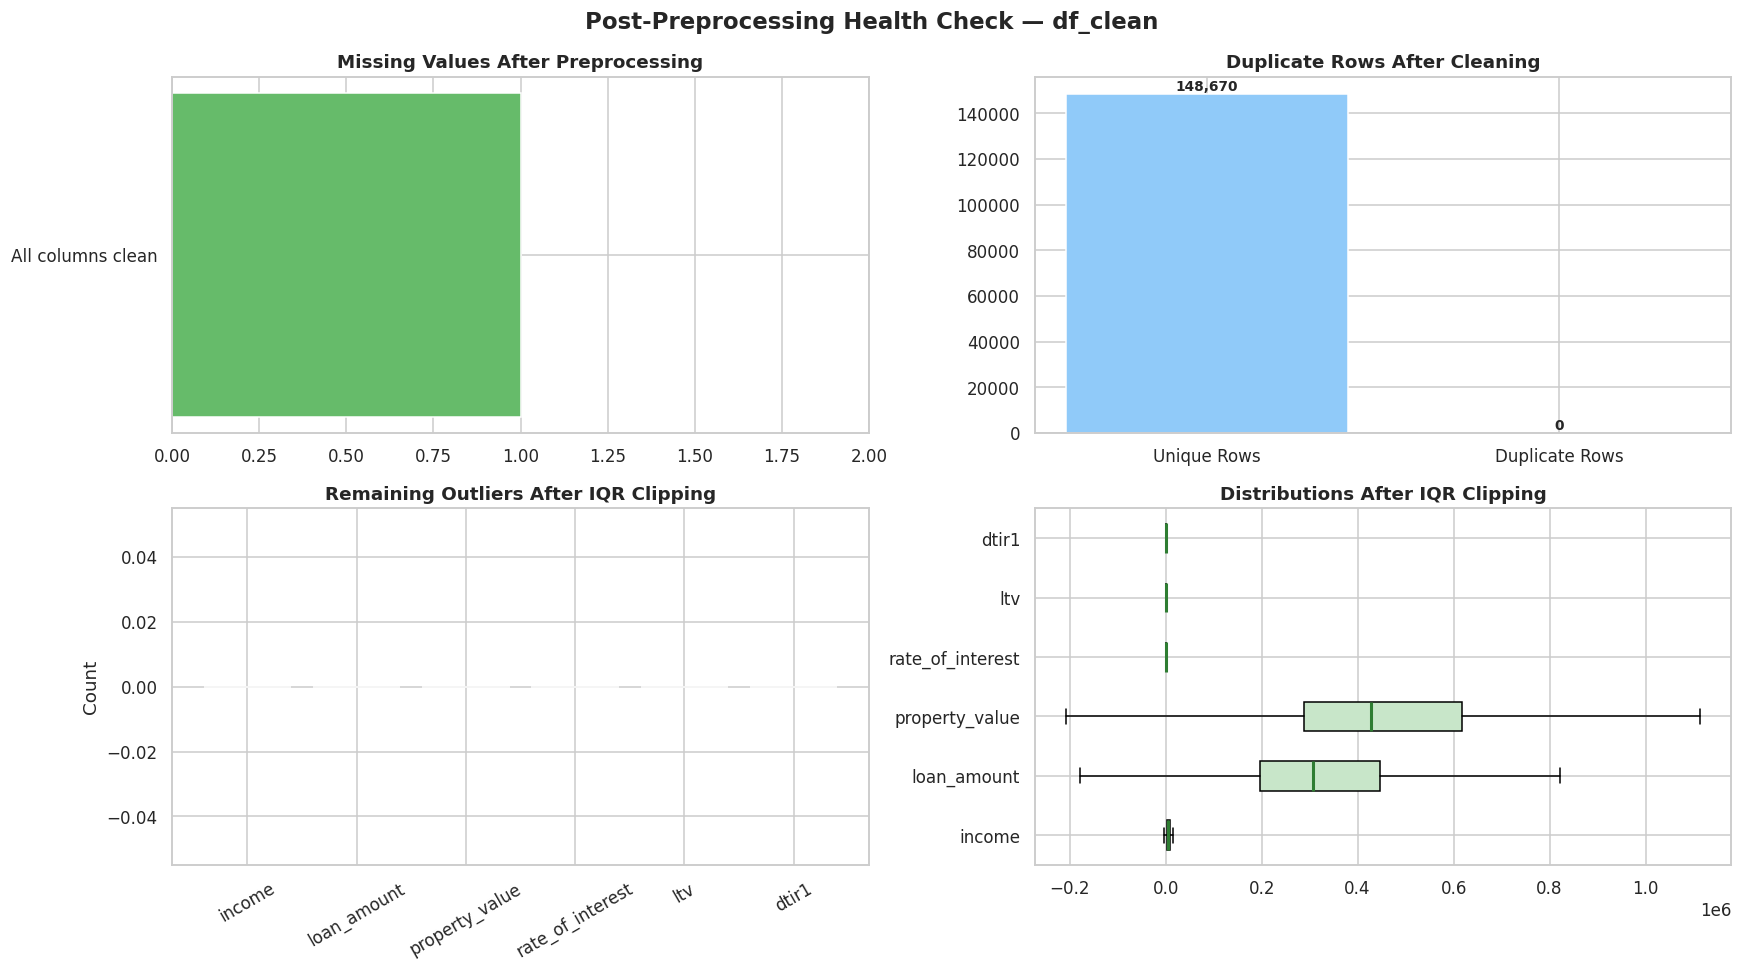

In [ ]:
# Graphical health check dashboard
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2)

# Panel 1: Missing values after
ax1 = fig.add_subplot(gs[0, 0])
if len(miss_after) > 0:
    ax1.barh(miss_after.index, miss_after.values, color='#EF6C00', edgecolor='white')
    ax1.set_xlabel('Missing Count')
else:
    ax1.barh(['All columns clean'], [1], color='#66BB6A', edgecolor='white')
    ax1.set_xlim(0, 2)
ax1.set_title('Missing Values After Preprocessing', fontweight='bold')

# Panel 2: Duplicates
ax2 = fig.add_subplot(gs[0, 1])
clean_count = len(df_clean) - dup_count
ax2.bar(['Unique Rows', 'Duplicate Rows'], [clean_count, dup_count],
        color=['#90CAF9', '#EF9A9A'], edgecolor='white')
ax2.set_title('Duplicate Rows After Cleaning', fontweight='bold')
for i, v in enumerate([clean_count, dup_count]):
    ax2.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Outlier counts post-clipping
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(list(outlier_after.keys()), list(outlier_after.values()),
        color='#8E24AA', edgecolor='white')
ax3.set_title('Remaining Outliers After IQR Clipping', fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
ax3.set_ylabel('Count')

# Panel 4: Box plots after clipping
ax4 = fig.add_subplot(gs[1, 1])
if iqr_target_cols:
    data_to_plot = [df_clean[col].dropna() for col in iqr_target_cols]
    ax4.boxplot(data_to_plot, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#C8E6C9'),
                medianprops=dict(color='#2E7D32', linewidth=2),
                labels=iqr_target_cols)
ax4.set_title('Distributions After IQR Clipping', fontweight='bold')

plt.suptitle('Post-Preprocessing Health Check — df_clean', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# BUG FIX: df_clean.describe() shown HERE — after preprocessing — not on raw df
print('Cleaned Dataset Statistics (df_clean — after all preprocessing):')
df_clean.describe().T.round(3)

Cleaned Dataset Statistics (df_clean — after all preprocessing):


,count,mean,std,min,25%,50%,75%,max
loan_amount,148670.0,332765.506,189657.280,-178500.000,196500.000,306500.000,446500.000,821500.000
rate_of_interest,148670.0,2.873,2.462,-3.853,1.084,3.750,4.375,9.312
interest_rate_spread,148670.0,0.546,1.266,-3.638,0.179,0.402,0.652,16.779
upfront_charges,148670.0,5160.729,21537.201,-18970.094,1250.000,2685.090,4068.503,299822.523
term,148670.0,344.352,115.493,-115.520,360.000,360.000,360.000,1797.780
property_value,148670.0,476471.991,275447.097,-207000.000,288000.000,428000.000,618000.000,1113000.000
income,148670.0,6588.133,4150.985,-3510.000,3780.000,5820.000,8640.000,15930.000
credit_score,148670.0,724.655,287.624,-291.638,598.000,701.643,806.000,4497.311
ltv,148670.0,73.492,20.274,26.379,62.127,75.202,85.959,121.707
status,148670.0,0.252,0.434,0.000,0.000,0.000,1.000,1.000


---
## SECTION 4 — Baseline Models (Before Advanced Preprocessing)

In [ ]:
# Baseline pipeline: imputation only — no IQR clipping, no scaling
DROP_COLS_BASE = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_base = df.drop(columns=DROP_COLS_BASE).copy()
df_base = df_base[df_base[TARGET].notna()].copy()

for col in df_base.select_dtypes(include=['int64','float64']).columns:
    if col != TARGET:
        df_base[col] = df_base[col].fillna(df_base[col].median())
for col in df_base.select_dtypes(include=['object']).columns:
    if col != TARGET:
        df_base[col] = df_base[col].fillna(df_base[col].mode()[0])

X_base = df_base.drop(columns=[TARGET])
y_base = df_base[TARGET]

X_base = pd.get_dummies(X_base, drop_first=True)
X_base.columns = X_base.columns.str.replace(r'[^a-zA-Z0-9_]','_',regex=True).str.strip('_')

leak = [c for c in X_base.columns if 'status' in c.lower()]
if leak:
    X_base = X_base.drop(columns=leak)

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_STATE, stratify=y_base
)

print(f'Baseline X shape: {X_base.shape}')
print('Baseline pipeline ready (imputation only — no IQR, no scaling)')

Baseline X shape: (148670, 50)
Baseline pipeline ready (imputation only — no IQR, no scaling)


In [ ]:
# Evaluation helpers — defined once here
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC AUC'  : round(roc_auc_score(y_te, y_prob), 4)
    }

def get_fresh_models():
    # Fresh instances every call — never reuse fitted model objects
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'XGBoost'            : XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                              eval_metric='logloss', verbosity=0)
    }

print('evaluate_model() and get_fresh_models() defined')

evaluate_model() and get_fresh_models() defined


In [ ]:
# Run baseline models
print('Training baseline models (minimal preprocessing)...')
before_results = {}
baseline_models = get_fresh_models()

for name, model in baseline_models.items():
    before_results[name] = evaluate_model(model, X_train_base, X_test_base,
                                           y_train_base, y_test_base)
    print(f'  {name} done')

before_df = pd.DataFrame(before_results).T
print()
print('BEFORE Advanced Preprocessing Results:')
before_df

Training baseline models (minimal preprocessing)...
  Logistic Regression done
  Random Forest done
  XGBoost done

BEFORE Advanced Preprocessing Results:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.9649,0.9334,0.9263,0.9299,0.9571
Random Forest,0.9895,0.9895,0.9684,0.9788,0.9833
XGBoost,0.9895,0.9891,0.9691,0.9790,0.9835


---
## SECTION 5 — Full Pipeline Models (After Advanced Preprocessing)

In [ ]:
# Run full pipeline models
print('Training full-pipeline models (IQR clipping + StandardScaler applied)...')
after_results = {}
full_models = get_fresh_models()

for name, model in full_models.items():
    after_results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)
    print(f'  {name} done')

after_df = pd.DataFrame(after_results).T
print()
print('AFTER Advanced Preprocessing Results:')
after_df

Training full-pipeline models (IQR clipping + StandardScaler applied)...
  Logistic Regression done
  Random Forest done
  XGBoost done

AFTER Advanced Preprocessing Results:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.9710,0.9490,0.9350,0.9419,0.9663
Random Forest,0.9895,0.9895,0.9686,0.9789,0.9830
XGBoost,0.9895,0.9891,0.9688,0.9789,0.9827


---
## SECTION 6 — Before vs After Comparison

In [ ]:
# Combined comparison table with delta
comparison = pd.DataFrame({
    'Before Accuracy' : before_df['Accuracy'],
    'After Accuracy'  : after_df['Accuracy'],
    'Before F1'       : before_df['F1 Score'],
    'After F1'        : after_df['F1 Score'],
    'Before ROC AUC'  : before_df['ROC AUC'],
    'After ROC AUC'   : after_df['ROC AUC'],
})
comparison['Accuracy Delta'] = (after_df['Accuracy']  - before_df['Accuracy']).round(4)
comparison['F1 Delta']       = (after_df['F1 Score']  - before_df['F1 Score']).round(4)
comparison['ROC AUC Delta']  = (after_df['ROC AUC']   - before_df['ROC AUC']).round(4)

comparison.style.map(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, float) and v > 0
    else ('color: red' if isinstance(v, float) and v < 0 else ''),
    subset=['Accuracy Delta', 'F1 Delta', 'ROC AUC Delta']
)

,Before Accuracy,After Accuracy,Before F1,After F1,Before ROC AUC,After ROC AUC,Accuracy Delta,F1 Delta,ROC AUC Delta
Logistic Regression,0.964900,0.971000,0.929900,0.941900,0.957100,0.966300,0.006100,0.012000,0.009200
Random Forest,0.989500,0.989500,0.978800,0.978900,0.983300,0.983000,0.000000,0.000100,-0.000300
XGBoost,0.989500,0.989500,0.979000,0.978900,0.983500,0.982700,0.000000,-0.000100,-0.000800


> **Interpretation note:** Logistic Regression shows the clearest gain after IQR clipping + scaling because it is a linear, distance-based model sensitive to outliers and unscaled features. Random Forest and XGBoost are tree-based — they split on feature thresholds and are naturally robust to outliers, so they may show little change. This is expected behaviour, not a failure of the pipeline.

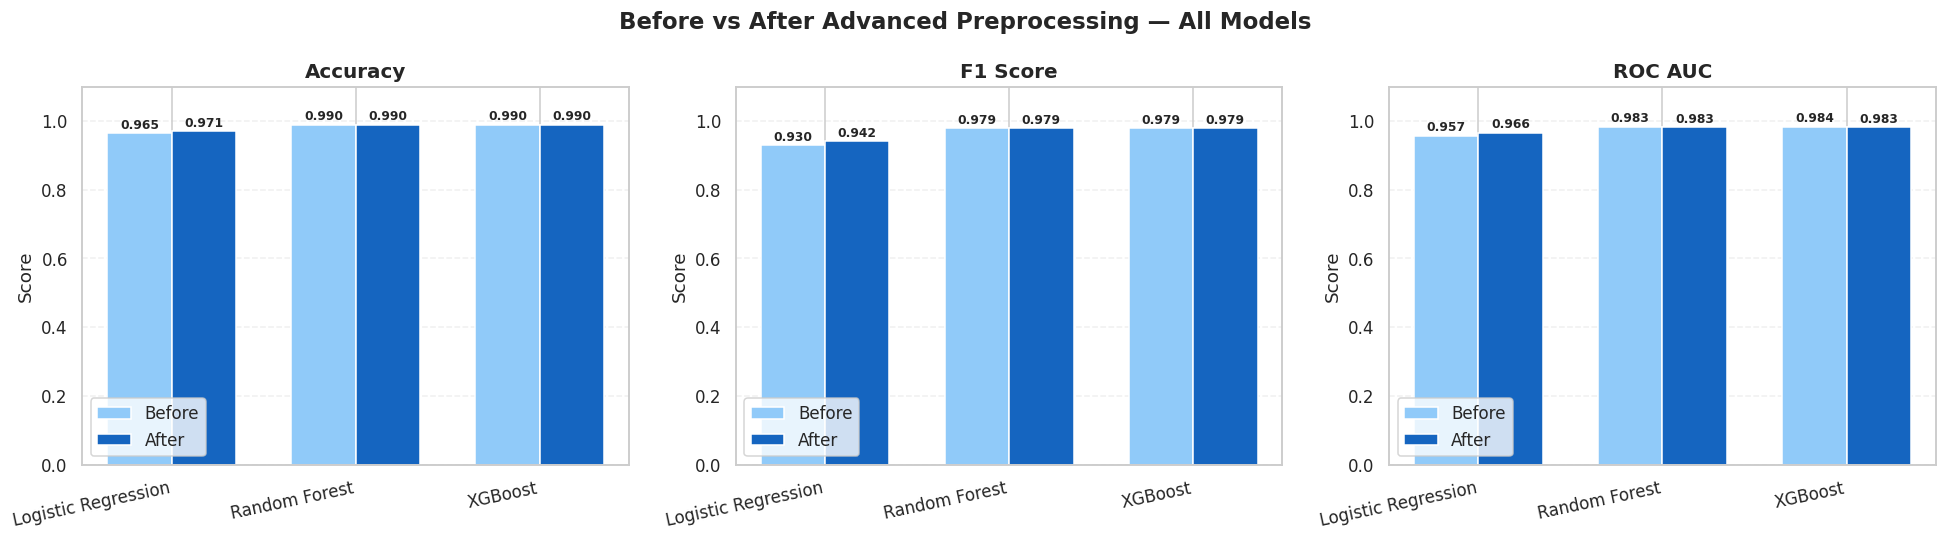

In [ ]:
# Grouped bar chart: Before vs After — all 3 metrics
metrics_to_plot = ['Accuracy', 'F1 Score', 'ROC AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = before_df.index.tolist()
x = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, metrics_to_plot):
    b_vals = before_df[metric].values
    a_vals = after_df[metric].values
    bars1 = ax.bar(x - width/2, b_vals, width, label='Before', color='#90CAF9', edgecolor='white')
    bars2 = ax.bar(x + width/2, a_vals, width, label='After',  color='#1565C0', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=12, ha='right')
    ax.set_ylim(0, 1.10)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Before vs After Advanced Preprocessing — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

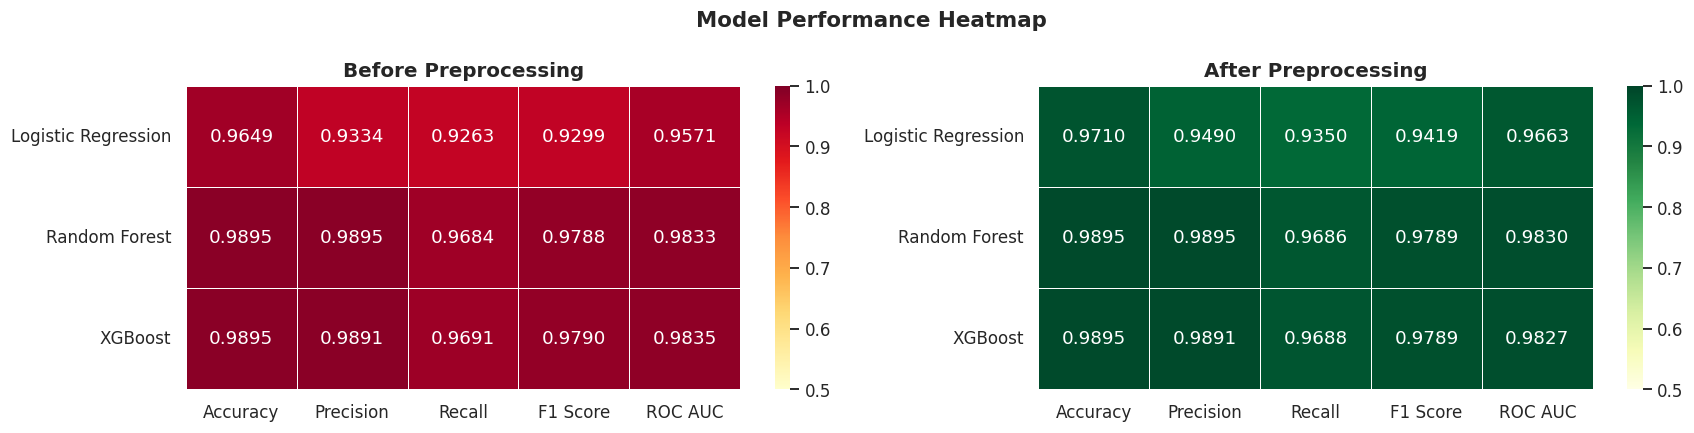

In [ ]:
# Heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(before_df.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.5, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Before Preprocessing', fontweight='bold', fontsize=13)

sns.heatmap(after_df.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('After Preprocessing', fontweight='bold', fontsize=13)

plt.suptitle('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 7 — Best Model Deep Dive

In [ ]:
best_model_name = after_df['F1 Score'].idxmax()
print(f'Best model by F1 Score: {best_model_name}')
print(after_df.loc[best_model_name])

Best model by F1 Score: Random Forest
Accuracy     0.9895
Precision    0.9895
Recall       0.9686
F1 Score     0.9789
ROC AUC      0.9830
Name: Random Forest, dtype: float64


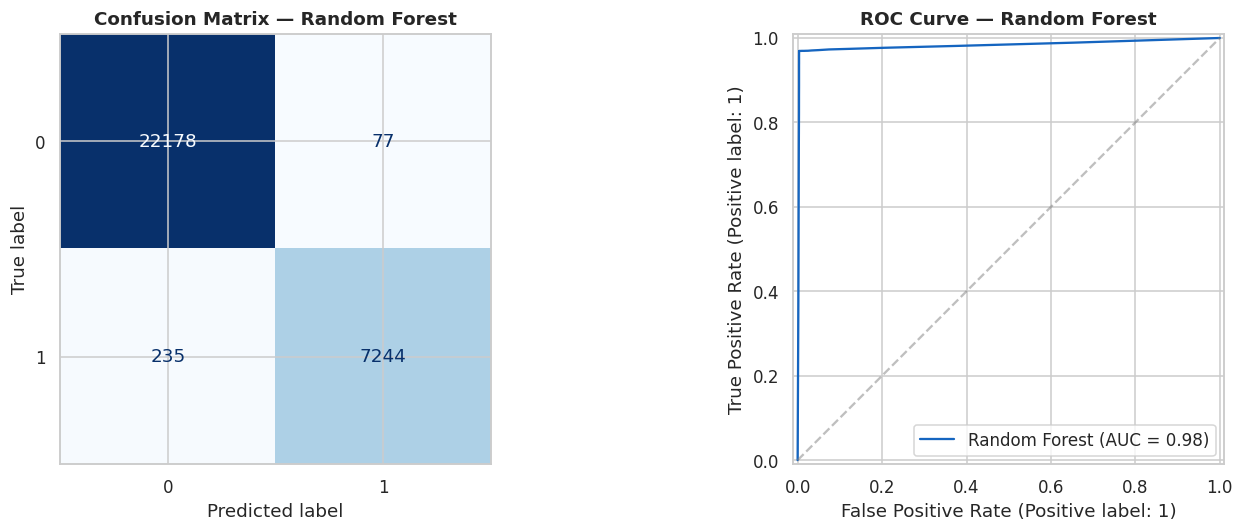

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     22255
           1       0.99      0.97      0.98      7479

    accuracy                           0.99     29734
   macro avg       0.99      0.98      0.99     29734
weighted avg       0.99      0.99      0.99     29734



In [ ]:
# Retrain fresh best model instance
best_model = get_fresh_models()[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1],
                                  name=best_model_name, color='#1565C0')
axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[1].set_title(f'ROC Curve — {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_test, y_pred_best))

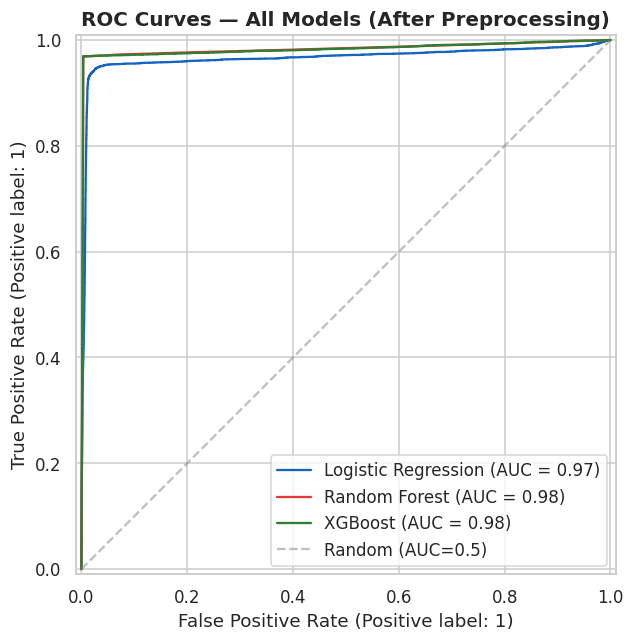

In [ ]:
# ROC curves — all 3 models overlaid
plt.figure(figsize=(9, 6))
colors_roc = ['#1565C0', '#E53935', '#2E7D32']

for (name, model), color in zip(full_models.items(), colors_roc):
    y_prob_m = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob_m, ax=plt.gca(),
                                      name=name, color=color)

plt.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random (AUC=0.5)')
plt.title('ROC Curves — All Models (After Preprocessing)', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

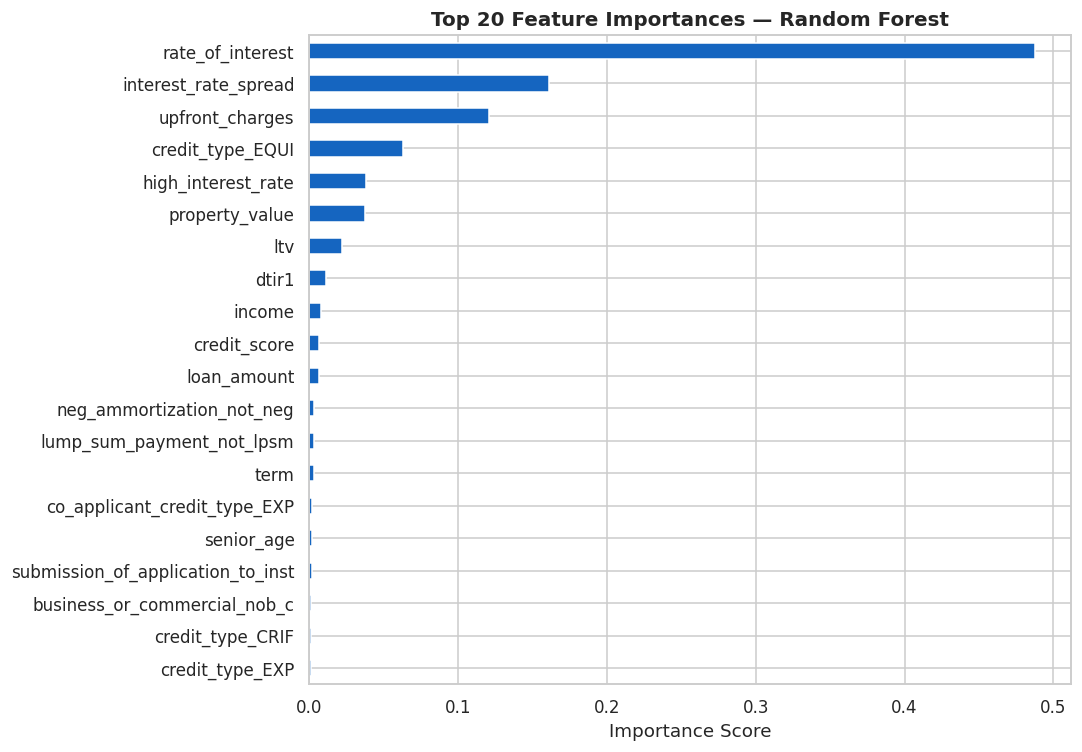

Fairness-sensitive features in top 20 — bias audit recommended:
  senior_age (importance: 0.0021)


In [ ]:
# Feature importance
importance_model_name = 'Random Forest' if 'Random Forest' in full_models else 'XGBoost'
importance_model = full_models[importance_model_name]

if hasattr(importance_model, 'feature_importances_'):
    feat_imp = pd.Series(
        importance_model.feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    feat_imp.plot(kind='barh', color='#1565C0', edgecolor='white')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 Feature Importances — {importance_model_name}', fontweight='bold', fontsize=13)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    fairness_in_top = [c for c in feat_imp.index
                       if any(f in c.lower() for f in ['gender','region','age','loan_limit'])]
    if fairness_in_top:
        print('Fairness-sensitive features in top 20 — bias audit recommended:')
        for f in fairness_in_top:
            print(f'  {f} (importance: {feat_imp[f]:.4f})')
    else:
        print('Fairness-sensitive features are not dominant predictors')

---
## SECTION 8 — Fairness Audit (SDG 10)
> Computes Statistical Parity Difference (SPD) and Disparate Impact Ratio (DIR) across demographic groups.

In [ ]:
# Attach fairness columns back to test set
test_idx = X_test_raw.index
df_test_fair = df_clean.loc[test_idx].copy()
df_test_fair['predicted'] = y_pred_best
df_test_fair['actual'] = y_test.values

fairness_audit_cols = [c for c in ['gender', 'region', 'loan_limit', 'loan_purpose', 'age']
                       if c in df_test_fair.columns]

fairness_results = []
for col in fairness_audit_cols:
    group_rates = df_test_fair.groupby(col)['predicted'].mean()
    if len(group_rates) >= 2:
        max_rate = group_rates.max()
        min_rate = group_rates.min()
        spd  = round(max_rate - min_rate, 4)
        dir_ = round(min_rate / max_rate, 4) if max_rate > 0 else None
        fairness_results.append({
            'Feature'                    : col,
            'Max Approval Group'         : group_rates.idxmax(),
            'Max Approval Rate'          : f'{max_rate:.1%}',
            'Min Approval Group'         : group_rates.idxmin(),
            'Min Approval Rate'          : f'{min_rate:.1%}',
            'Stat. Parity Diff (SPD)'    : spd,
            'Disparate Impact Ratio (DIR)': dir_,
            'Biased?'                    : 'YES' if (dir_ is not None and dir_ < 0.8) else 'NO'
        })

if fairness_results:
    fairness_df = pd.DataFrame(fairness_results)
    print('Fairness Audit Results:')
    print('  SPD  ideal = 0   (gap in approval rates between best and worst group)')
    print('  DIR  ideal = 1.0 (below 0.8 = legally recognized discrimination threshold)')
    print()
    display(fairness_df)
else:
    print('No fairness-sensitive columns found in test data')

Fairness Audit Results:
  SPD  ideal = 0   (gap in approval rates between best and worst group)
  DIR  ideal = 1.0 (below 0.8 = legally recognized discrimination threshold)



,Feature,Max Approval Group,Max Approval Rate,Min Approval Group,Min Approval Rate,Stat. Parity Diff (SPD),Disparate Impact Ratio (DIR),Biased?
0,gender,Sex Not Available,28.3%,Joint,19.4%,0.0892,0.6846,YES
1,region,North-East,27.9%,North,23.0%,0.0490,0.8241,OK
2,loan_limit,ncf,33.7%,cf,24.0%,0.0976,0.7106,YES
3,loan_purpose,p2,33.5%,p4,23.1%,0.1041,0.6893,YES
4,age,<25,35.1%,35-44,22.3%,0.1277,0.6362,YES


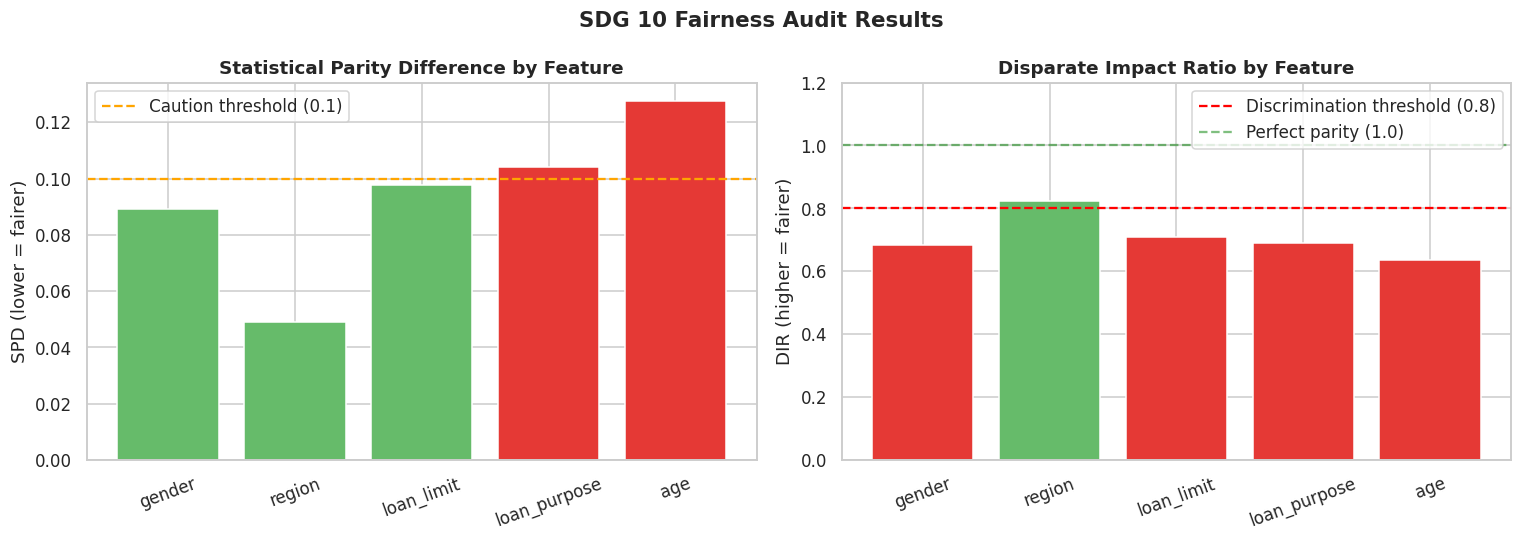

In [ ]:
# Fairness audit visualization
if fairness_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # SPD bar chart
    spd_vals = [r['Stat. Parity Diff (SPD)'] for r in fairness_results]
    features  = [r['Feature'] for r in fairness_results]
    bar_colors = ['#E53935' if v > 0.1 else '#66BB6A' for v in spd_vals]
    axes[0].bar(features, spd_vals, color=bar_colors, edgecolor='white')
    axes[0].axhline(0.1, color='orange', linestyle='--', label='Caution threshold (0.1)')
    axes[0].set_title('Statistical Parity Difference by Feature', fontweight='bold')
    axes[0].set_ylabel('SPD (lower = fairer)')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=20)

    # DIR bar chart
    dir_vals = [r['Disparate Impact Ratio (DIR)'] for r in fairness_results]
    bar_colors2 = ['#E53935' if v < 0.8 else '#66BB6A' for v in dir_vals]
    axes[1].bar(features, dir_vals, color=bar_colors2, edgecolor='white')
    axes[1].axhline(0.8, color='red', linestyle='--', label='Discrimination threshold (0.8)')
    axes[1].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Perfect parity (1.0)')
    axes[1].set_title('Disparate Impact Ratio by Feature', fontweight='bold')
    axes[1].set_ylabel('DIR (higher = fairer)')
    axes[1].set_ylim(0, 1.2)
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=20)

    plt.suptitle('SDG 10 Fairness Audit Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## SECTION 9 — Final Summary & Export

In [ ]:
print('=' * 65)
print('      EQUILOAN — FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print()
print('BEFORE Advanced Preprocessing:')
print(before_df.to_string())
print()
print('AFTER Advanced Preprocessing (IQR + StandardScaler):')
print(after_df.to_string())
print()
print('Improvement (After - Before):')
delta = after_df.astype(float) - before_df.astype(float)
print(delta.round(4).to_string())
print()
print('=' * 65)
print(f'Best model by F1 : {best_model_name}')
print(f'  Accuracy : {after_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'  F1 Score : {after_df.loc[best_model_name, "F1 Score"]:.4f}')
print(f'  ROC AUC  : {after_df.loc[best_model_name, "ROC AUC"]:.4f}')
print('=' * 65)

      EQUILOAN — FINAL MODEL COMPARISON SUMMARY

BEFORE Advanced Preprocessing:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.9649     0.9334  0.9263    0.9299   0.9571
Random Forest          0.9895     0.9895  0.9684    0.9788   0.9833
XGBoost                0.9895     0.9891  0.9691    0.9790   0.9835

AFTER Advanced Preprocessing (IQR + StandardScaler):
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.9710     0.9490  0.9350    0.9419   0.9663
Random Forest          0.9895     0.9895  0.9686    0.9789   0.9830
XGBoost                0.9895     0.9891  0.9688    0.9789   0.9827

Improvement (After - Before):
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.0061     0.0156  0.0087    0.0120   0.0092
Random Forest          0.0000     0.0000  0.0002    0.0001  -0.0003
XGBoost                0.0000     0.0000 -0.0003   -0.0001  -0.0008

Best model by F1 :

In [ ]:
# Export CSVs
before_df.to_csv('Before_Preprocessing_Results.csv')
after_df.to_csv('After_Preprocessing_Results.csv')
comparison.to_csv('Before_After_Comparison.csv')
if fairness_results:
    fairness_df.to_csv('Fairness_Audit_Results.csv', index=False)

print('Results saved:')
print('  Before_Preprocessing_Results.csv')
print('  After_Preprocessing_Results.csv')
print('  Before_After_Comparison.csv')
if fairness_results:
    print('  Fairness_Audit_Results.csv')

Results saved:
  Before_Preprocessing_Results.csv
  After_Preprocessing_Results.csv
  Before_After_Comparison.csv
  Fairness_Audit_Results.csv
